## **Imports**

In [1]:
import math
import os
import json
import time
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from tqdm import tqdm

import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/mohammad.yeganegi/documents/codes/diffusion_policy/")
sys.path.insert(0, str(PROJECT_ROOT))

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *
from diffusion_policy.CFM.path.affine import CondOTProbPath
from diffusion_policy.model.diffusion.conditional_unet1d import Unet1D
from diffusion_policy.CFM.cfm_model import CFMVectorField
from diffusion_policy.CFM.ode_solver import ODESolver
import copy
from diffusion_policy.model.common.lr_scheduler import get_scheduler
from diffusers.training_utils import EMAModel
from functools import partial
from diffusion_policy.CFM.path.affine import normal_log_prob
from matplotlib.ticker import MultipleLocator
from torch.utils.data import DataLoader
from diffusion_policy.common.pytorch_util import dict_apply, optimizer_to


/home/mohammad.yeganegi/miniconda3/envs/torchcfm/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


## **Functions**

In [2]:
def skewed_timestep_sample(num_samples: int, device: torch.device) -> torch.Tensor:
    P_mean = -1.2
    P_std = 1.2
    rnd_normal = torch.randn((num_samples,), device=device)
    sigma = (rnd_normal * P_std + P_mean).exp()
    time = 1 / (1 + sigma)
    time = torch.clip(time, min=0.0001, max=1.0)
    return time


def compute_nll(x1, solver, prior_std=1.0, exact_divergence=True):
    time_grid = torch.tensor([1.0, 0.0])

    _, logp = solver.compute_likelihood(
        x_1=x1,
        log_p0=partial(normal_log_prob, std=prior_std),
        time_grid=time_grid,
        exact_divergence=exact_divergence,
        method="dopri5",
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False,
        enable_grad=False,
    )

    # action_normalizer = self.normalizer['action']
    # scale = action_normalizer.params_dict['scale'].to(
    #     device=x1.device,
    #     dtype=x1.dtype,
    # )
    # # The action normalizer applies an affine transform z = s * x + b.
    # # For a change of variables, the density in the original space gets an
    # # extra log-absolute-Jacobian term: sum(log |s|) per action coordinate.
    # # Since the transform is applied independently at each action step, the
    # # total Jacobian for a x_1ectory with T action steps is T * sum(log |s|).
    # log_abs_det = x1.shape[1] * torch.log(scale.abs()).sum()

    # logp = logp + log_abs_det

    # Normalize by the number of action dimensions so the reported NLL is
    # comparable across different action shapes and horizons.
    num_dims = x1[0].numel()
    nll_ = -logp.mean() / num_dims
    return nll_


def compute_nll_over_loader(dataloader, solver, device, prior_std=1.0, exact_divergence=True):
    """
    Compute the (sample-weighted) mean NLL/dimension over an entire
    dataloader by looping over its mini-batches, instead of running the
    exact-divergence dopri5 solve on the whole test set in one giant batch
    (which is what actually causes the CUDA OOM -- the dataloader's
    batch_size controls how many samples get pushed through the ODE solver
    at once here, not just how the data is fetched).
    """
    total_weighted_nll = 0.0
    total_count = 0
    for batch in dataloader:
        x1_batch = (
            batch.to(device, non_blocking=True)
            if device.type == "cuda"
            else batch.to(device)
        )
        nll_batch = compute_nll(
            x1_batch,
            solver,
            prior_std=prior_std,
            exact_divergence=exact_divergence,
        )
        total_weighted_nll += nll_batch.item() * x1_batch.shape[0]
        total_count += x1_batch.shape[0]
    return total_weighted_nll / total_count


def sample_two_stage(solver, x_init, cutoff, device, return_intermediates=False, num_stage1_points=20):
    """
    Look-ahead sampler for a model trained only on t in [0, cutoff]:
      - [0, cutoff]: standard multi-step adaptive integration (dopri5), the
        range the marginalized VF was actually trained on.
      - [cutoff, 1.0]: a single Euler step, relying on the observation that
        the marginalized VF is already (near) straight past `cutoff`.

    Returns (x_init, x_cutoff, x_1): the source samples, the state at
    t=cutoff, and the one-step prediction at t=1 (all with the same shape
    as x_init). If return_intermediates=True, also returns `flow`: the full
    trajectory (dense over [0, cutoff] via `num_stage1_points` query times,
    then the two endpoints of the single Euler step to t=1) for visualizing
    the movement from source samples to the final distribution. Querying
    dopri5's dense output at more points doesn't add extra model
    evaluations -- it's cheap, just more interpolated output points from
    the same adaptive solve.
    """
    if return_intermediates:
        time_grid_stage1 = torch.linspace(0.0, cutoff, num_stage1_points, device=device)
    else:
        time_grid_stage1 = torch.tensor([0.0, cutoff], device=device)

    stage1_out = solver.sample(
        x_init=x_init,
        time_grid=time_grid_stage1,
        method="dopri5",
        step_size=None,
        atol=1e-6,
        rtol=1e-6,
        return_intermediates=return_intermediates,
        enable_grad=False,
    )
    x_cutoff = stage1_out[-1] if return_intermediates else stage1_out

    # Stage 2: evaluate the model once at (x_cutoff, cutoff) and take a
    # single explicit Euler step to t=1 -- same pattern as the oracle step
    # in `sample_two_stage_oracle`.global_cond_dim
    t_cutoff = torch.full((x_cutoff.shape[0],), cutoff, device=device)
    u_cutoff = solver.velocity_model(x=x_cutoff, t=t_cutoff)
    x_1 = x_cutoff + (1.0 - cutoff) * u_cutoff

    if return_intermediates:
        # Single extra point at t=1.0 appended to the dense stage-1 flow.
        flow = torch.cat([stage1_out, x_1.unsqueeze(0)], dim=0)
        return x_init, x_cutoff, x_1, flow

    return x_init, x_cutoff, x_1

def marginalized_vector_field_from_data(x_t, t, x1_pool, prior_std=1.0, sigma=0.0):
    """
    Compute the marginalized ("oracle") vector field at (x_t, t) directly
    from real data, using the exact same posterior-weighted-average formula
    the marginalized VF training loss is built on (see
    `vectorized_computation` in diffusion_policy/CFM/path/affine.py, called
    from `AffineProbPath.sample`) -- but with every entry of `x1_pool`
    treated as an ordinary candidate. `vectorized_computation` always
    forces its first candidate to be the "true" x1 that generated x_t
    during training; at inference x_t (e.g. x_cutoff) didn't come from any
    particular real x1 -- it came from integrating noise through the model
    -- so there's no "true" candidate to single out here, just a plain
    marginalization over the candidate pool.

    Args:
        x_t: [B, H, D] current states at time t (e.g. x_cutoff).
        t: [B] time values in [0, 1).
        x1_pool: [N, H, D] pool of real target samples (e.g. test data)
            used as the empirical marginal distribution.
        prior_std: std of the source Gaussian p(x_0).
        sigma: CondOT scheduler's sigma (same value as CFM.sigma).

    Returns:
        ut: [B, H, D] the data-based marginalized velocity at (x_t, t).
    """
    b, h, d = x_t.shape
    n = x1_pool.shape[0]

    x_t_flat = x_t.reshape(b, -1)
    x1_pool_flat = x1_pool.reshape(n, -1)

    deno = 1 - (1 - sigma) * t  # [B]

    x_t_exp = x_t_flat.unsqueeze(1)          # [B, 1, D]
    x1_pool_exp = x1_pool_flat.unsqueeze(0)  # [1, N, D]
    t_exp = t.view(b, 1, 1)
    deno_exp = deno.view(b, 1, 1)

    # Implied x0 under each candidate, exactly as in vectorized_computation.
    x0_xbar = (x_t_exp - t_exp * x1_pool_exp) / deno_exp  # [B, N, D]

    logprob = normal_log_prob(x0_xbar.reshape(b * n, -1), prior_std).view(b, n)
    logprob = logprob - logprob.max(dim=1, keepdim=True).values
    prob = torch.exp(logprob)
    norm_prob = prob / prob.sum(dim=1, keepdim=True)  # [B, N]

    v = (x1_pool_exp - (1 - sigma) * x_t_exp) / deno_exp  # [B, N, D]
    ut = torch.sum(norm_prob.unsqueeze(2) * v, dim=1)  # [B, D]

    return ut.view(b, h, d)

def sample_two_stage_oracle(
    solver, x_init, cutoff, x1_pool, device, prior_std=1.0, sigma=0.0
):
    """
    Two-stage sampler where stage 1 (t in [0, cutoff]) integrates normally
    with the TRAINED model via dopri5 -- exactly as in `sample_two_stage`
    -- but stage 2's single step to t=1 uses the marginalized vector field
    computed directly from real data (`x1_pool`) at (x_cutoff, cutoff),
    instead of the model's own prediction there (see
    `marginalized_vector_field_from_data`). This isolates whether a poor
    model-based one-step jump comes from the network failing to learn the
    marginalized field, or from the marginalized field itself not being
    straight enough for a one-step jump to work.

    Returns (x_init, x_cutoff, x_1).
    """
    time_grid_stage1 = torch.tensor([0.0, cutoff], device=device)
    x_cutoff = solver.sample(
        x_init=x_init,
        time_grid=time_grid_stage1,
        method="dopri5",
        step_size=None,
        atol=1e-6,
        rtol=1e-6,
        return_intermediates=False,
        enable_grad=False,
    )

    t_cutoff = torch.full((x_cutoff.shape[0],), cutoff, device=device)
    u_oracle = marginalized_vector_field_from_data(
        x_cutoff, t_cutoff, x1_pool, prior_std=prior_std, sigma=sigma
    )
    x_1 = x_cutoff + (1.0 - cutoff) * u_oracle

    return x_init, x_cutoff, x_1


def sample_two_stage_full_oracle(x_init, cutoff, x1_pool, device, prior_std=1.0, sigma=0.0):
    """
    Like `sample_two_stage_oracle`, but stage 1 (t in [0, cutoff]) also
    integrates the data-based marginalized vector field
    (`marginalized_vector_field_from_data`) via dopri5, instead of the
    trained model -- so the model is never touched in either stage. This
    isolates the marginalized-VF sampler itself (formula + integration)
    from any error the network introduces when approximating it.

    Returns (x_init, x_cutoff, x_1).
    """

    def oracle_velocity(x, t):
        if t.ndim == 0:
            t = t.expand(x.shape[0])
        t = t.to(device=x.device, dtype=x.dtype)
        return marginalized_vector_field_from_data(
            x, t, x1_pool, prior_std=prior_std, sigma=sigma
        )

    oracle_solver = ODESolver(oracle_velocity)

    time_grid_stage1 = torch.tensor([0.0, cutoff], device=device)
    x_cutoff = oracle_solver.sample(
        x_init=x_init,
        time_grid=time_grid_stage1,
        method="dopri5",
        step_size=None,
        atol=1e-6,
        rtol=1e-6,
        return_intermediates=False,
        enable_grad=False,
    )

    t_cutoff = torch.full((x_cutoff.shape[0],), cutoff, device=device)
    u_oracle = marginalized_vector_field_from_data(
        x_cutoff, t_cutoff, x1_pool, prior_std=prior_std, sigma=sigma
    )
    x_1 = x_cutoff + (1.0 - cutoff) * u_oracle

    return x_init, x_cutoff, x_1


def sample_x1_vf_batch(dataset, batch_size: int) -> torch.Tensor:
    total_samples = len(dataset)
    if total_samples == 0:
        return torch.empty(0)

    random_indices = torch.randint(0, total_samples, (batch_size,))
    batch_data = torch.stack(
        [torch.from_numpy(dataset[idx.item()]) for idx in random_indices]
    )
    return batch_data


## Plots

In [3]:
def plot_all_training_losses(
    results,
    savepath=None,
    smoothing=200,
):
    """
    Plot training loss for all VF batch sizes on one figure.

    results[vf_batch_size] should contain:
        {
            "training_steps": [...],
            "training_losses": [...],
            "nll_steps": [...],
            "nll_scores": [...]
        }
    """

    fig, ax = plt.subplots()

    for vf_batch_size, result in results.items():
        steps = np.asarray(result["training_steps"])
        losses = np.asarray(result["training_losses"])

        if smoothing > 1 and len(losses) >= smoothing:
            kernel = np.ones(smoothing) / smoothing

            smoothed = np.convolve(
                losses,
                kernel,
                mode="valid",
            )

            smoothed_steps = steps[smoothing - 1 :]

            ax.plot(
                smoothed_steps,
                smoothed,
                label=f"VF batch size = {vf_batch_size}",
            )
        else:
            ax.plot(
                steps,
                losses,
                label=f"VF batch size = {vf_batch_size}",
            )

    ax.set_xlabel("Training step")
    ax.set_ylabel("MSE loss")
    ax.set_title("Training loss")
    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(
            savepath,
            dpi=200,
            bbox_inches="tight",
        )

    plt.grid(True)
    plt.show()
    plt.close(fig)


def plot_all_nlls(
    results,
    savepath=None,
):
    """
    Plot NLL for all VF batch sizes on one figure.
    """

    fig, ax = plt.subplots()

    for vf_batch_size, result in results.items():
        steps = np.asarray(result["nll_steps"])
        nll = np.asarray(result["nll_scores"])

        ax.plot(
            steps,
            nll,
            marker="o",
            markersize=3,
            label=f"VF batch size = {vf_batch_size}",
        )

    ax.set_xlabel("Training step")
    ax.set_ylabel("NLL / dimension")
    ax.set_title("Negative log-likelihood")
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    # ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()
    plt.grid(True)

    if savepath is not None:
        fig.savefig(
            savepath,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


def plot_my_trajectories(solver, x1, plot_size, device, savepath=None, num_flow_points=20):
    """Plot trajectories of some selected samples."""

    x_0 = torch.randn(plot_size, x1.shape[1], x1.shape[2], device=device)

    # Densely-spaced query times so the "Flow" scatter below actually shows
    # intermediate movement -- with just the 2 endpoints [0.0, 1.0], the
    # returned trajectory only has the start/end states (dopri5's dense
    # output is evaluated exactly at the requested time_grid points), so the
    # "Flow" layer would just redraw the same two point-clouds already
    # plotted as z(0)/z(1), invisibly. Querying more points is cheap: it
    # doesn't add extra model evaluations, just more interpolated points
    # from the same adaptive solve.
    time_grid = torch.linspace(0.0, 1.0, num_flow_points, device=x_0.device)
    # integrate the ODE backwards in time
    x_1 = solver.sample(
        x_init=x_0,
        time_grid=time_grid,
        method="dopri5",
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=True,
        enable_grad=False,
    )
    x_1 = x_1.flatten(2).cpu()
    x1 = x1.flatten(1).cpu()
    # evaluate FID score
    # x1_gen = x_1[-1,:,:]
    # fid_score = fid.fid_from_feats(x1_gen, x1_plot)
    n = 2000
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(x_1[0, :n, 0], x_1[0, :n, 1], s=10, alpha=0.6, c="black")
    plt.scatter(x_1[:, :n, 0], x_1[:, :n, 1], s=0.2, alpha=0.1, c="olive")
    plt.scatter(x1[:, 0], x1[:, 1], s=4, alpha=0.6, c="red")
    plt.scatter(x_1[-1, :n, 0], x_1[-1, :n, 1], s=4, alpha=0.6, c="blue")
    plt.legend(["Prior sample z(0)", "Flow", "z(1)", "Targets"])
    plt.grid(True)

    if savepath is not None:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")


def plot_lookahead_trajectories(solver, x1, plot_size, cutoff, device, savepath=None):
    """
    Look-ahead sampling diagnostic for a model trained only on t in [0, cutoff]:
    dopri5 from t=0 to t=cutoff, then a single Euler step from cutoff to t=1
    (see `sample_two_stage`). Plots z(0), the flow from z(0) to z(cutoff),
    z(cutoff), the one-step z(1), and targets.
    """

    x_0 = torch.randn(plot_size, x1.shape[1], x1.shape[2], device=device)

    x_init, x_cutoff, x_1, flow = sample_two_stage(
        solver, x_0, cutoff, device, return_intermediates=True
    )

    flow = flow.flatten(2).cpu()
    x_init = x_init.flatten(1).cpu()
    x_cutoff = x_cutoff.flatten(1).cpu()
    x_1 = x_1.flatten(1).cpu()
    x1 = x1.flatten(1).cpu()

    n = 2000
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(x_init[:n, 0], x_init[:n, 1], s=4, alpha=0.5, c="black")
    plt.scatter(flow[:, :n, 0], flow[:, :n, 1], s=0.2, alpha=0.1, c="olive")
    plt.scatter(x_cutoff[:n, 0], x_cutoff[:n, 1], s=4, alpha=0.5, c="green")
    plt.scatter(x1[:, 0], x1[:, 1], s=4, alpha=0.6, c="red")
    plt.scatter(x_1[:n, 0], x_1[:n, 1], s=4, alpha=0.6, c="blue")
    plt.legend(
        ["z(0)", "Flow", f"z({cutoff}) after dopri5", "Targets", "z(1) after 1-step Euler"]
    )
    plt.title(f"Look-ahead sampling: dopri5 [0,{cutoff}] + 1 Euler step [{cutoff},1]")
    plt.grid(True)

    if savepath is not None:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")

    plt.show()


def plot_oracle_lookahead_trajectories(
    solver, x1, plot_size, cutoff, x1_pool, device, prior_std=1.0, sigma=0.0, savepath=None
):
    """
    Like `plot_lookahead_trajectories`, but stage 2's single step to t=1
    uses the marginalized vector field computed directly from real data
    (`x1_pool`) at (x_cutoff, cutoff), instead of the model's own
    prediction there (see `sample_two_stage_oracle` /
    `marginalized_vector_field_from_data`).
    """

    x_0 = torch.randn(plot_size, x1.shape[1], x1.shape[2], device=device)

    x_init, x_cutoff, x_1 = sample_two_stage_oracle(
        solver, x_0, cutoff, x1_pool, device, prior_std=prior_std, sigma=sigma
    )

    x_init = x_init.flatten(1).cpu()
    x_cutoff = x_cutoff.flatten(1).cpu()
    x_1 = x_1.flatten(1).cpu()
    x1 = x1.flatten(1).cpu()

    n = 2000
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(x_init[:n, 0], x_init[:n, 1], s=4, alpha=0.5, c="black")
    plt.scatter(x_cutoff[:n, 0], x_cutoff[:n, 1], s=4, alpha=0.5, c="green")
    plt.scatter(x1[:, 0], x1[:, 1], s=4, alpha=0.6, c="red")
    plt.scatter(x_1[:n, 0], x_1[:n, 1], s=4, alpha=0.6, c="blue")
    plt.legend(
        [
            "z(0)",
            f"z({cutoff}) after dopri5 (model)",
            "Targets",
            "z(1) after data-based VF step"
        ]
    )
    plt.title(
        f"sampling: dopri5 [0,{cutoff}] (model) + "
        f"1 step [{cutoff},1] using data-based marginalized VF"
    )
    plt.grid(True)

    if savepath is not None:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")

    plt.show()


def plot_full_oracle_lookahead_trajectories(
    x1, plot_size, cutoff, x1_pool, device, prior_std=1.0, sigma=0.0, savepath=None
):
    """
    Like `plot_oracle_lookahead_trajectories`, but stage 1 also uses the
    data-based marginalized vector field instead of the trained model (see
    `sample_two_stage_full_oracle`) -- the model is never touched in
    either stage.
    """

    x_0 = torch.randn(plot_size, x1.shape[1], x1.shape[2], device=device)

    x_init, x_cutoff, x_1 = sample_two_stage_full_oracle(
        x_0, cutoff, x1_pool, device, prior_std=prior_std, sigma=sigma
    )

    x_init = x_init.flatten(1).cpu()
    x_cutoff = x_cutoff.flatten(1).cpu()
    x_1 = x_1.flatten(1).cpu()
    x1 = x1.flatten(1).cpu()

    n = 2000
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(x_init[:n, 0], x_init[:n, 1], s=4, alpha=0.5, c="black")
    plt.scatter(x_cutoff[:n, 0], x_cutoff[:n, 1], s=4, alpha=0.5, c="green")
    plt.scatter(x1[:, 0], x1[:, 1], s=4, alpha=0.6, c="red")
    plt.scatter(x_1[:n, 0], x_1[:n, 1], s=4, alpha=0.6, c="blue")
    plt.legend(
        [
            "z(0)",
            f"z({cutoff}) after dopri5 (data-based VF)",
            "Targets",
            "z(1) after data-based VF step",
        ]
    )
    plt.title(
        f"sampling: dopri5 [0,{cutoff}] + "
        f"1 step [{cutoff},1], both using data-based marginalized VF"
    )
    plt.grid(True)

    if savepath is not None:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")

    plt.show()


def plot_probabilities_over_time(
        times: torch.Tensor,
        probs: torch.Tensor,
        save_path: str,
    ):
        """
        Args:
            times: [B]
            probs: [B, N]

        For each time times[b], plot all N probability values
        probs[b, :] vertically at that time.
        """

        times = times.detach().cpu()
        probs = probs.detach().cpu()

        # # Sort by time
        # idx = torch.argsort(times)
        # times = times[idx]
        # probs = probs[idx]

        times = times.numpy()
        probs = probs.numpy()

        fig, ax = plt.subplots(figsize=(12, 6))

        B, N = probs.shape

        # Repeat each time N times:
        # [t0, t1, ..., tB] -> [t0,t0,...,t1,t1,...]
        x = np.repeat(times, N)

        # Flatten probabilities row-wise:
        # [[p00,p01,...],
        #  [p10,p11,...], ...]
        # -> [p00,p01,...,p10,p11,...]
        y = probs.reshape(-1)

        # Color according to n
        colors = plt.cm.viridis(np.linspace(0, 1, B))
        colors = np.repeat(colors, N, axis=0)

        ax.scatter(
            x,
            y,
            s=2,
            alpha=1,
            color=colors,
        )

        ax.set_xlabel("Time")
        ax.set_ylabel("Probability")
        # ax.set_xlim(-0.2, 1.2)
        # ax.set_ylim(-0.2, 1.2)

        ax.grid(True, alpha=0.3)

        fig.savefig(save_path, dpi=150)
        plt.close(fig)


## Dataset

In [4]:
def generate_moons(
    n_samples: int = 100,
    T: int = 10,
    noise=0.02,
    seed=None,
):
    """
    Generate n_samples sequences of length T of 2D two-moons coordinates.

    Returns
    -------
    torch.Tensor of shape (n_samples, T, 2), dtype=float32, on CPU.
    """
    rng = np.random.default_rng(seed)

    total = n_samples * T
    n_outer = total // 2
    n_inner = total - n_outer

    # First moon
    outer_theta = np.linspace(0, np.pi, n_outer)
    outer_x = np.cos(outer_theta)
    outer_y = np.sin(outer_theta)

    # Second moon
    inner_theta = np.linspace(0, np.pi, n_inner)
    inner_x = 1 - np.cos(inner_theta)
    inner_y = 1 - np.sin(inner_theta) - 0.5

    # Combine
    X = np.concatenate(
        [np.column_stack([outer_x, outer_y]), np.column_stack([inner_x, inner_y])]
    )

    # Shuffle
    permutation = rng.permutation(total)
    X = X[permutation]

    # Add noise
    if noise is not None:
        X += rng.normal(loc=0.0, scale=noise, size=X.shape)

    # Reshape into sequences
    X = X * 2 - 1
    X = X.reshape(n_samples, T, 2).astype(np.float32)

    # Convert to torch tensor (keep on CPU for DataLoader)
    return torch.from_numpy(X)


## **Training**

### Setup

In [5]:
# ---------- Setup ----------
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")

batch_size = 126
TRAINING_UPDATES = 20000
skewed_timesteps = False
VF_BATCH_SIZES = [0, 10000]
NTESTS = int(TRAINING_UPDATES / 5)
HORIZON = 52  # must be divisible by 4: ConditionalUnet1D's 3-level down_dims
              # below has 2 downsample stages, each halving the sequence length
DIM = 2
TRAIN_TIME_CUTOFF = 0.4
INFERENCE_CUTOFF = 0.4
assert INFERENCE_CUTOFF <= TRAIN_TIME_CUTOFF

sigma = 0.01
train_size = 10000
test_size = 3000

# Model architecture, kept together so it can be saved verbatim in config.json.
MODEL_KWARGS = dict(
    input_dim=DIM,
    diffusion_step_embed_dim=256,
    down_dims=[256, 512, 1024],
    kernel_size=5,
    n_groups=8,
    cond_predict_scale=True,
)

# ---------- Output directory for this run ----------
# Every run gets its own outputs/<timestamp>/ folder containing all plots,
# model checkpoints, and a config.json recording the hyperparameters used.
OUTPUT_ROOT = "outputs"
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = os.path.join(OUTPUT_ROOT, run_id)
os.makedirs(run_dir, exist_ok=True)

config = dict(
    run_id=run_id,
    batch_size=batch_size,
    TRAINING_UPDATES=TRAINING_UPDATES,
    skewed_timesteps=skewed_timesteps,
    VF_BATCH_SIZES=VF_BATCH_SIZES,
    NTESTS=NTESTS,
    HORIZON=HORIZON,
    DIM=DIM,
    TRAIN_TIME_CUTOFF=TRAIN_TIME_CUTOFF,
    INFERENCE_CUTOFF=INFERENCE_CUTOFF,
    sigma=sigma,
    train_size=train_size,
    test_size=test_size,
    model_kwargs=MODEL_KWARGS,
)
with open(os.path.join(run_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print(f"Run directory: {run_dir}")

CFM = CondOTProbPath(sigma=sigma)

# Generate data – both are tensors on CPU with shape (n_samples, HORIZON, 2)
train_data = generate_moons(n_samples=train_size, T=HORIZON, seed=123)
test_data = generate_moons(n_samples=test_size, T=HORIZON, seed=456)

num_workers = min(4, os.cpu_count() or 1) if device.type == "cuda" else 1

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(num_workers > 0),
    shuffle=True,
)

# Same batch_size as training: evaluation (NLL, sample generation) loops
# over this in mini-batches rather than pushing the whole test set through
# the ODE solver at once, which is what actually causes CUDA OOM (see
# `compute_nll_over_loader` and the plotting calls below).
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(num_workers > 0),
    shuffle=False,
)
print(f"training dataset length: {len(train_dataloader.dataset)}")


Run directory: outputs/20260921_193102
training dataset length: 10000


### Debug: probability-over-time diagnostic

In [6]:
# ---------- Debug: probability-over-time diagnostic (marginalized VF) ----------
# This is a diagnostic only (no training happens here): it shows, for the
# marginalized VF batch size, how concentrated the softmax weight on the
# "true" candidate x1[i] is as a function of t.
times = []
probs_all = []
vf_batch_size_debug = VF_BATCH_SIZES[1]  # Use the marginalized VF batch size for this test

for batch in train_dataloader:
    # batch shape: (batch_size, HORIZON, 2)
    x1 = (
        batch.to(device, non_blocking=True)
        if device.type == "cuda"
        else batch.to(device)
    )
    x0 = torch.randn_like(x1)  # same shape

    indices = torch.randint(0, len(train_data), (vf_batch_size_debug,))
    x1_vf_batch = (
        train_data[indices].to(device, non_blocking=True)
        if device.type == "cuda"
        else train_data[indices].to(device)
    )

    # Sample time
    if skewed_timesteps:
        t = skewed_timestep_sample(x1.shape[0], device=device)
    else:
        t = torch.rand(x1.shape[0], device=device)

    out, first_element_prob, norm_score, prob = CFM.sample(
        x0,
        x1,
        t,
        x1_vf_batch,
        prior_std=1.0,
        debug=True,
    )
    t = out.t
    times.append(t)
    probs_all.append(prob)

times = torch.cat(times, dim=0)
probs_all = torch.cat(probs_all, dim=0)
plot_probabilities_over_time(
    times, probs_all, os.path.join(run_dir, "probability_vs_time.png")
)

print(f"Debug plot uses VF batch size = {vf_batch_size_debug}.")


Debug plot uses VF batch size = 10000.


### Training loop (look-ahead time cutoff for the marginalized VF)


Training with VF batch size = 0
  -> t restricted to [0, 0.4] at train time
  -> inference uses two-stage sampler with cutoff = 0.4


Training VF batch size=0:   0%|          | 1/20000 [00:00<2:00:04,  2.78it/s, loss=3.16043, lr=2.00e-06]

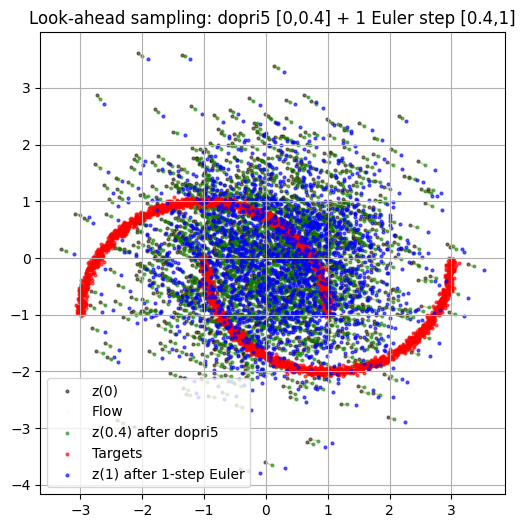

Training VF batch size=0: 100%|██████████| 20000/20000 [20:00<00:00, 21.51it/s, loss=2.61687, lr=0.00e+00]

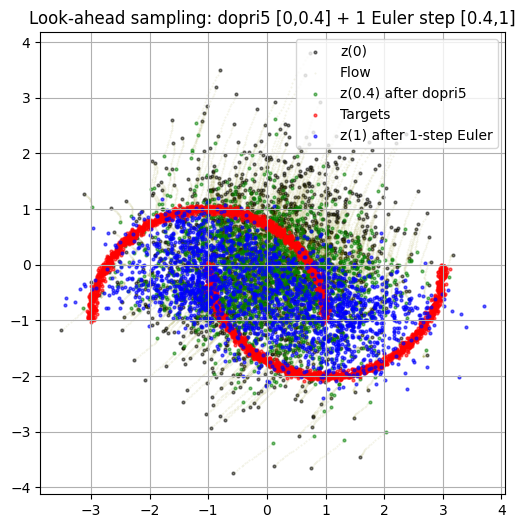

Finished VF batch size = 0

Training with VF batch size = 10000
  -> t restricted to [0, 0.4] at train time
  -> inference uses two-stage sampler with cutoff = 0.4


Training VF batch size=0: 100%|██████████| 20000/20000 [20:47<00:00, 16.03it/s, loss=2.61687, lr=0.00e+00]


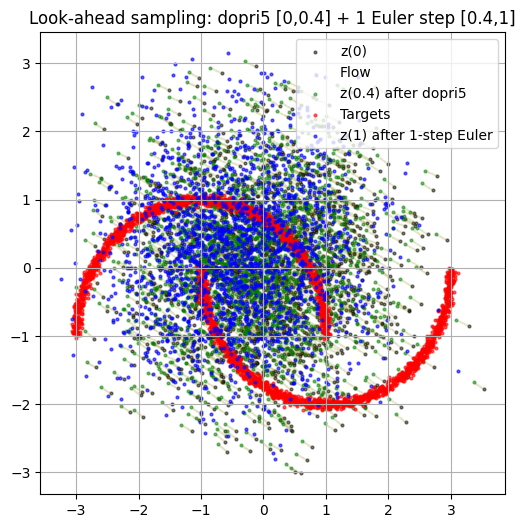

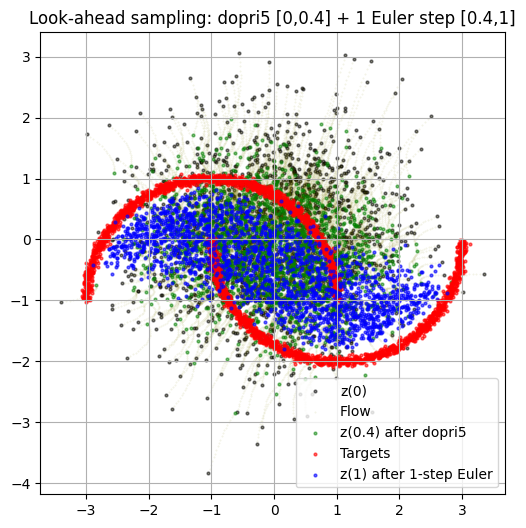

Finished VF batch size = 10000


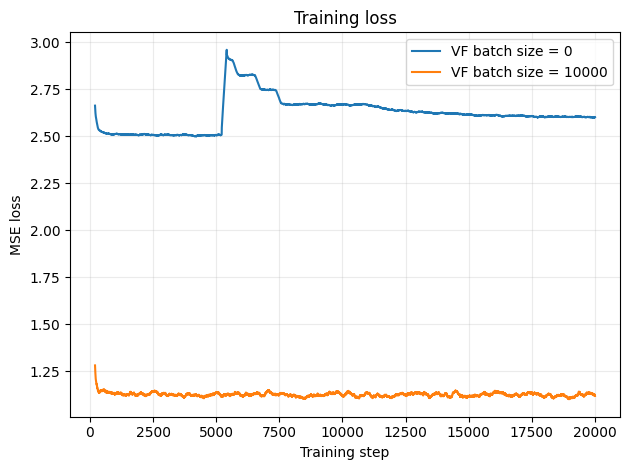

In [7]:
results = {}
trained_models = {}  # keep the trained model for each vf_batch_size around for later comparison

# ---------- Training loop ----------
# Both vf_batch_size=0 (standard CFM loss) and vf_batch_size>0 (marginalized
# VF loss) are trained identically here: t restricted to [0, TRAIN_TIME_CUTOFF]
# (default 1.0, i.e. full-range [0, 1] training for both). Evaluation always
# uses the two-stage look-ahead sampler at INFERENCE_CUTOFF; when
# TRAIN_TIME_CUTOFF=1.0 the models are also valid everywhere, so we
# additionally compute NLL and a full multi-step dopri5 trajectory plot for
# direct comparison against the look-ahead shortcut.
#
# Both NLL and sample generation loop over test_dataloader / use batch_size
# at a time -- pushing the whole test set through the ODE solver in one
# shot is what causes CUDA OOM, not the data loading itself.
for vf_batch_size in VF_BATCH_SIZES:
    print("\n" + "=" * 60)
    print(f"Training with VF batch size = {vf_batch_size}")
    print(f"  -> t restricted to [0, {TRAIN_TIME_CUTOFF}] at train time")
    print(f"  -> inference uses two-stage sampler with cutoff = {INFERENCE_CUTOFF}")
    print("=" * 60)

    global_step = 0

    model = Unet1D(**MODEL_KWARGS)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters())
    lr_scheduler = get_scheduler(
        "cosine",
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=TRAINING_UPDATES,
        last_epoch=-1,
    )
    optimizer_to(optimizer, device)

    # EMAModel deep-copies `model` internally into `ema.averaged_model` --
    # that's the object `ema.step(model)` actually updates. A separate
    # `ema_model = copy.deepcopy(model)` passed in here would NOT be the
    # same object and would never be touched by `ema.step()`, silently
    # staying at its random initialization forever.
    ema = EMAModel(
        model=model,
        update_after_step=0,
        inv_gamma=1.0,
        power=0.75,
        min_value=0.0,
        max_value=0.9999,
        device=device,
    )

    MSE = torch.nn.MSELoss()

    training_steps = []
    training_losses = []
    nll_steps = []
    nll_scores = []

    pbar = tqdm(
        total=TRAINING_UPDATES,
        desc=f"Training VF batch size={vf_batch_size}",
        dynamic_ncols=True,
    )

    while global_step < TRAINING_UPDATES:
        for batch in train_dataloader:
            if global_step >= TRAINING_UPDATES:
                break

            # batch shape: (batch_size, HORIZON, 2)
            x1 = (
                batch.to(device, non_blocking=True)
                if device.type == "cuda"
                else batch.to(device)
            )
            x0 = torch.randn_like(x1)  # same shape

            # Sample additional sequences for marginal VF estimation
            if vf_batch_size > 0:
                indices = torch.randint(0, len(train_data), (vf_batch_size,))
                x1_vf_batch = (
                    train_data[indices].to(device, non_blocking=True)
                    if device.type == "cuda"
                    else train_data[indices].to(device)
                )
            else:
                x1_vf_batch = None

            # Sample time, restricted to [0, TRAIN_TIME_CUTOFF] for both
            # models. With TRAIN_TIME_CUTOFF=1.0 (default) this is a no-op
            # and both models train on the full [0, 1] range as usual.
            if skewed_timesteps:
                t = skewed_timestep_sample(x1.shape[0], device=device)
            else:
                t = torch.rand(x1.shape[0], device=device)
            t = t * TRAIN_TIME_CUTOFF

            out = CFM.sample(
                x0,
                x1,
                t,
                x1_vf_batch,
                prior_std=1.0,
                debug=False,
            )

            x_t = out.x_t.to(device)
            u_t = out.dx_t.to(device)

            vt_pred = model(x_t, t)
            loss = MSE(vt_pred, u_t)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            ema.step(model)

            global_step += 1
            training_steps.append(global_step)
            training_losses.append(loss.item())

            pbar.update(1)
            pbar.set_postfix(
                loss=f"{loss.item():.5f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )

            # Evaluation. NLL and the full multi-step dopri5 trajectory plot
            # are only valid when the model was trained on the full [0, 1]
            # range (TRAIN_TIME_CUTOFF=1.0). The look-ahead two-stage plot
            # (dopri5 up to INFERENCE_CUTOFF + 1 Euler step to t=1) is shown
            # at the start/end of training whenever INFERENCE_CUTOFF < 1.0 --
            # at exactly 1.0 there's no time left for a second stage, so
            # `sample_two_stage` would get a degenerate [1.0, 1.0] interval.
            # Evaluation always uses the EMA weights (ema.averaged_model),
            # not the raw model.
            is_full_range = TRAIN_TIME_CUTOFF >= 1.0
            is_ntest_step = is_full_range and (global_step % NTESTS == 0 or global_step == 1)
            is_plot_step = global_step == 1 or global_step == TRAINING_UPDATES
            if is_ntest_step or is_plot_step:
                ema.averaged_model.eval()
                with torch.no_grad():
                    vector_field = CFMVectorField(ema.averaged_model)
                    solver = ODESolver(vector_field)

                    # if is_ntest_step:
                    #     # Loops over test_dataloader in batch_size chunks --
                    #     # avoids running the exact-divergence dopri5 solve on
                    #     # the whole test set at once.
                    #     nll_value = compute_nll_over_loader(test_dataloader, solver, device)
                    #     nll_steps.append(global_step)
                    #     nll_scores.append(nll_value)

                    if is_plot_step:
                        # test_data is already a full CPU tensor -- used
                        # directly for the "Targets" scatter (no network
                        # pass needed). Only `batch_size` fresh prior samples
                        # are generated through the ODE solver at once, to
                        # keep the sampling itself from causing OOM too.
                        if is_full_range:
                            plot_my_trajectories(
                                solver,
                                test_data,
                                test_size,
                                device=device,
                                savepath=os.path.join(
                                    run_dir,
                                    f"trajectories_vfbs{vf_batch_size}_step{global_step:06d}.png",
                                ),
                            )

                        if INFERENCE_CUTOFF < 1.0:
                            plot_lookahead_trajectories(
                                solver,
                                test_data,
                                test_size,
                                INFERENCE_CUTOFF,
                                device=device,
                                savepath=os.path.join(
                                    run_dir,
                                    f"lookahead_vfbs{vf_batch_size}_step{global_step:06d}.png",
                                ),
                            )

                ema.averaged_model.train()

    # Save results for this experiment
    results[vf_batch_size] = {
        "training_steps": training_steps,
        "training_losses": training_losses,
        "nll_steps": nll_steps,
        "nll_scores": nll_scores,
    }

    torch.save(
        results[vf_batch_size],
        os.path.join(run_dir, f"results_vfbs_{vf_batch_size}.pt"),
    )

    # Save the EMA weights (not the raw model) so this run can be reloaded
    # later (see the "Load a previous run" cell) without retraining.
    torch.save(
        ema.averaged_model.state_dict(),
        os.path.join(run_dir, f"model_vfbs_{vf_batch_size}.pt"),
    )

    trained_models[vf_batch_size] = ema.averaged_model
    print(f"Finished VF batch size = {vf_batch_size}")

# ---------- Plotting ----------
plot_all_training_losses(
    results,
    savepath=os.path.join(run_dir, "training_loss.png"),
    smoothing=200,
)
if TRAIN_TIME_CUTOFF >= 1.0:
    plot_all_nlls(
        results,
        savepath=os.path.join(run_dir, "nll.png"),
    )


## **Look-Ahead Evaluation**

Baseline (standard CFM, dopri5 [0, 0.4] + 1 Euler step [0.4, 1]):


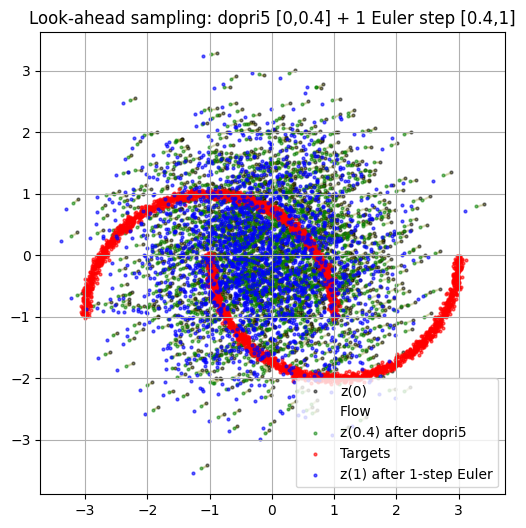

Look-ahead (marginalized VF, dopri5 [0, 0.4] + 1 Euler step [0.4, 1]):


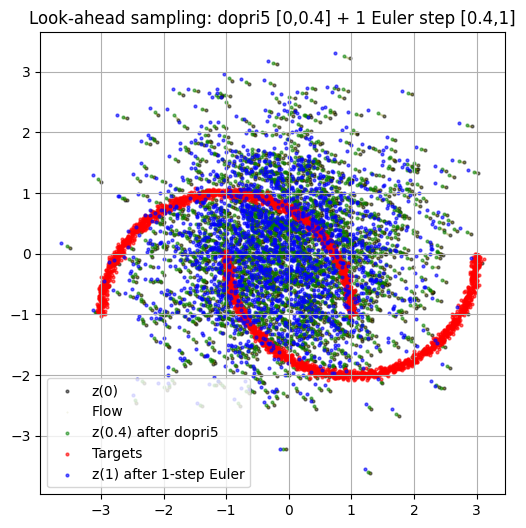


All outputs for this run saved under: outputs/20260921_180801


In [8]:
# ---------- Look-ahead inference comparison ----------
# Both models were trained the same way, on t in [0, TRAIN_TIME_CUTOFF]. Here
# we always evaluate with the two-stage look-ahead sampler: dopri5 over
# [0, INFERENCE_CUTOFF] then a single Euler step over [INFERENCE_CUTOFF, 1]
# (see `sample_two_stage`) -- shown whenever INFERENCE_CUTOFF < 1.0 (at
# exactly 1.0 there's no second stage left to test). When
# TRAIN_TIME_CUTOFF=1.0 the models are also valid everywhere, so we
# additionally show the full multi-step dopri5 result as a quality
# reference to compare the shortcut against.
#   (a) baseline: vf_batch_size=0 (standard conditional flow-matching loss)
#   (b) look-ahead: vf_batch_size=VF_BATCH_SIZES[1] (marginalized VF loss)
#
# test_data (the full CPU tensor) is used directly for the "Targets"
# scatter; only `batch_size` fresh prior samples are pushed through the ODE
# solver at once, to avoid the OOM that a whole-test-set batch would cause.

baseline_model = trained_models[0]
lookahead_model = trained_models[VF_BATCH_SIZES[1]]

baseline_solver = ODESolver(CFMVectorField(baseline_model))
lookahead_solver = ODESolver(CFMVectorField(lookahead_model))

baseline_model.eval()
lookahead_model.eval()

INFERENCE_CUTOFF = 0.4
is_full_range = INFERENCE_CUTOFF >= 1.0

with torch.no_grad():
    if is_full_range:
        print("Baseline (standard CFM, full dopri5 over [0, 1] -- quality reference):")
        plot_my_trajectories(
            baseline_solver,
            test_data,
            test_size,
            device=device,
            savepath=os.path.join(run_dir, "final_trajectories_baseline.png"),
        )

        print("Marginalized VF (full dopri5 over [0, 1] -- quality reference):")
        plot_my_trajectories(
            lookahead_solver,
            test_data,
            test_size,
            device=device,
            savepath=os.path.join(run_dir, "final_trajectories_marginalized.png"),
        )

    if INFERENCE_CUTOFF < 1.0:
        print(
            f"Baseline (standard CFM, dopri5 [0, {INFERENCE_CUTOFF}] "
            f"+ 1 Euler step [{INFERENCE_CUTOFF}, 1]):"
        )
        plot_lookahead_trajectories(
            baseline_solver,
            test_data,
            test_size,
            INFERENCE_CUTOFF,
            device=device,
            savepath=os.path.join(run_dir, "final_lookahead_baseline.png"),
        )

        print(
            f"Look-ahead (marginalized VF, dopri5 [0, {INFERENCE_CUTOFF}] "
            f"+ 1 Euler step [{INFERENCE_CUTOFF}, 1]):"
        )
        plot_lookahead_trajectories(
            lookahead_solver,
            test_data,
            test_size,
            INFERENCE_CUTOFF,
            device=device,
            savepath=os.path.join(run_dir, "final_lookahead_marginalized.png"),
        )

print(f"\nAll outputs for this run saved under: {run_dir}")


## **Load a Previous Run**

Oracle pool size: 10000 samples
Baseline (standard CFM) -- dopri5 [0,0.4] with the model, then a data-based (oracle) marginalized-VF step to t=1:


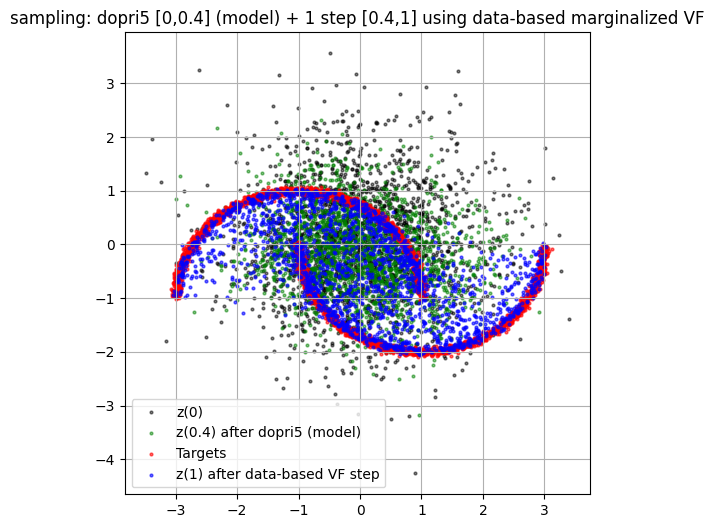

Look-ahead (marginalized VF) -- dopri5 [0,0.4] with the model, then a data-based (oracle) marginalized-VF step to t=1:


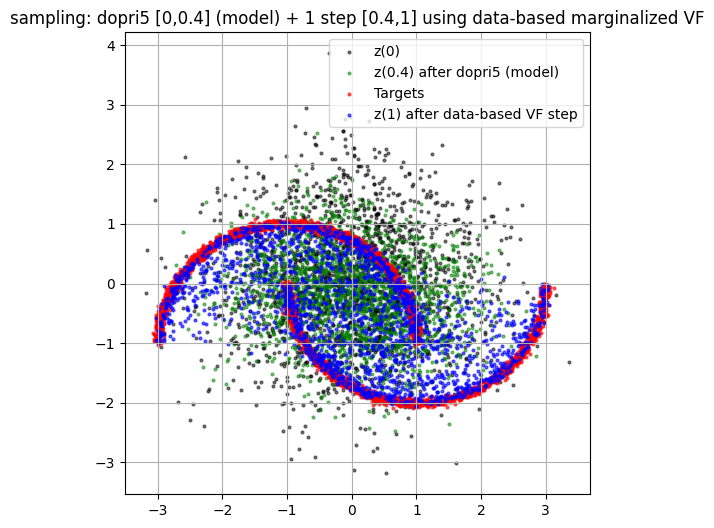

Full-oracle (no model) -- dopri5 [0,0.4] then 1 step [0.4,1], both using the data-based marginalized VF:


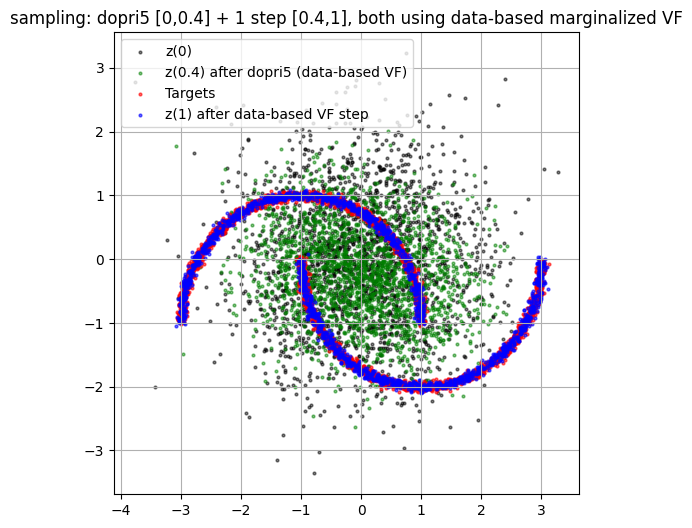


Loaded and replotted run: outputs/20260921_121228


In [16]:
# ---------- Data-based (oracle) two-stage sampling ----------
# Point PREV_RUN_DIR at any run folder under outputs/<run_id>/ (from this
# notebook or a prior one). Loads that run's config.json to reconstruct its
# model_kwargs/HORIZON/etc., rebuilds the model(s), and loads their trained
# weights from model_vfbs_{vf_batch_size}.pt -- so this cell can be re-run
# standalone (e.g. after a kernel restart, or against an older run) without
# retraining and without depending on any variable from the cells above.
#
# Stage 1 (t in [0, INFERENCE_CUTOFF]) is unchanged: integrate normally
# with the trained model via dopri5.
# Stage 2 (t in [INFERENCE_CUTOFF, 1]) no longer takes a single Euler step
# using the MODEL's predicted velocity at (x_cutoff, INFERENCE_CUTOFF).
# Instead it computes the marginalized vector field directly from real
# data: x_cutoff plays the role of `x_t`, and a pool of real test-set
# samples plays the role of the candidate `x_1`s, plugged into the exact
# same posterior-weighted-average formula the marginalized VF loss itself
# is built on (see `vectorized_computation` in
# diffusion_policy/CFM/path/affine.py, and `marginalized_vector_field_from_data`
# / `sample_two_stage_oracle` in the Functions section above). This isolates
# whether a poor one-step jump comes from the network failing to learn the
# marginalized field, or from the marginalized field itself not being
# straight enough for a one-step jump to work.
#
# Also plots the full-oracle variant (`plot_full_oracle_lookahead_trajectories`
# / `sample_two_stage_full_oracle`), where BOTH stages use the data-based
# marginalized VF and the trained model is never touched at all -- this
# isolates the marginalized-VF sampler itself from any error the network
# introduces when approximating it.

PREV_RUN_DIR = os.path.join("outputs", "20260921_121228")  # <- set to any previous run's folder

with open(os.path.join(PREV_RUN_DIR, "config.json")) as f:
    prev_config = json.load(f)

prev_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# generate_moons is deterministic given (n_samples, T, seed), and the Setup
# cell above always uses seed=456 for the test split -- so this reproduces
# the exact same test set the run was evaluated against.
prev_test_data = generate_moons(
    n_samples=prev_config["test_size"],
    T=prev_config["HORIZON"],
    seed=456,
)
prev_train_data = generate_moons(
    n_samples=prev_config["train_size"],
    T=prev_config["HORIZON"],
    seed=123,
)

all_data = torch.cat([prev_train_data, prev_test_data], dim=0)
#ORACLE_POOL_SIZE = min(prev_config["test_size"], 10000)  # candidate x_1's for the oracle vector field
ORACLE_POOL_SIZE = min(prev_config["train_size"], 10000)  # candidate x_1's for the oracle vector field
#ORACLE_POOL_SIZE = min(prev_config["train_size"] + prev_config["test_size"], 100000)  # candidate x_1's for the oracle vector field


def load_run_model(run_dir, model_kwargs, vf_batch_size, device):
    model = Unet1D(**model_kwargs)
    state_dict = torch.load(
        os.path.join(run_dir, f"model_vfbs_{vf_batch_size}.pt"),
        map_location=device,
    )
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


oracle_baseline_model = load_run_model(PREV_RUN_DIR, prev_config["model_kwargs"], 0, prev_device)
oracle_lookahead_model = load_run_model(
    PREV_RUN_DIR, prev_config["model_kwargs"], prev_config["VF_BATCH_SIZES"][1], prev_device
)

oracle_baseline_solver = ODESolver(CFMVectorField(oracle_baseline_model))
oracle_lookahead_solver = ODESolver(CFMVectorField(oracle_lookahead_model))

# Real test-set samples used as the oracle vector field's candidate pool
# (the x_1's in the marginalized-VF formula -- x_cutoff plays the role of x_t).
#oracle_indices = torch.randperm(prev_config["test_size"])[:ORACLE_POOL_SIZE]
#x1_pool = prev_test_data[oracle_indices].to(prev_device)
oracle_indices = torch.randperm(prev_config["train_size"])[:ORACLE_POOL_SIZE]
x1_pool = prev_train_data[oracle_indices].to(prev_device)
# oracle_indices = torch.randperm(prev_config["train_size"] + prev_config["test_size"])[:ORACLE_POOL_SIZE]
# x1_pool = all_data[oracle_indices].to(prev_device)
print (f"Oracle pool size: {x1_pool.shape[0]} samples")
with torch.no_grad():
    print(
        f"Baseline (standard CFM) -- dopri5 [0,{prev_config['INFERENCE_CUTOFF']}] with the "
        f"model, then a data-based (oracle) marginalized-VF step to t=1:"
    )
    plot_oracle_lookahead_trajectories(
        oracle_baseline_solver,
        prev_test_data,
        prev_config["test_size"],
        prev_config["INFERENCE_CUTOFF"],
        x1_pool,
        device=prev_device,
        prior_std=1.0,
        sigma=prev_config["sigma"],
        savepath=os.path.join(PREV_RUN_DIR, "reload_oracle_lookahead_baseline.png"),
    )

    print(
        f"Look-ahead (marginalized VF) -- dopri5 [0,{prev_config['INFERENCE_CUTOFF']}] with "
        f"the model, then a data-based (oracle) marginalized-VF step to t=1:"
    )
    plot_oracle_lookahead_trajectories(
        oracle_lookahead_solver,
        prev_test_data,
        prev_config["test_size"],
        prev_config["INFERENCE_CUTOFF"],
        x1_pool,
        device=prev_device,
        prior_std=1.0,
        sigma=prev_config["sigma"],
        savepath=os.path.join(PREV_RUN_DIR, "reload_oracle_lookahead_marginalized.png"),
    )

    print(
        f"Full-oracle (no model) -- dopri5 [0,{prev_config['INFERENCE_CUTOFF']}] then "
        f"1 step [{prev_config['INFERENCE_CUTOFF']},1], both using the data-based "
        f"marginalized VF:"
    )
    plot_full_oracle_lookahead_trajectories(
        prev_test_data,
        prev_config["test_size"],
        prev_config["INFERENCE_CUTOFF"],
        x1_pool,
        device=prev_device,
        prior_std=1.0,
        sigma=prev_config["sigma"],
        savepath=os.path.join(PREV_RUN_DIR, "reload_full_oracle_lookahead.png"),
    )

print(f"\nLoaded and replotted run: {PREV_RUN_DIR}")